### Data Preparation

In [11]:
from arch import arch_model
import numpy as np
import numba
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import statsmodels.api as sm
import itertools
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from scipy.stats import boxcox

#Import XLF Data
path = "/Users/joshuawong/Desktop/etf_series.hf5"
data = pd.read_hdf(path,"XLF")
data = data.ffill()
data = data.reset_index()
data['Date'] = pd.to_datetime(data['Date'])
data = data.dropna(subset=['Close'])

#Import VIX Data
VIX_path = "/Users/joshuawong/Downloads/data_vix.csv"
VIX_data = pd.read_csv(VIX_path)
VIX_data = VIX_data.ffill()
VIX_data['Date'] = pd.to_datetime(VIX_data['Date'])
VIX_data = VIX_data.dropna(subset=['Adj Close'])
VIX_data = VIX_data[['Date', 'Adj Close']]
VIX_data = VIX_data.rename(columns={'Adj Close': 'VIX Adj Close'})
data1 = data.merge(VIX_data, on='Date', how='inner')
data1 = data1.dropna()

#Import Fed Funds Rate Data
FFR_path = "/Users/joshuawong/Downloads/RIFSPFFNB.csv"
FFR_data = pd.read_csv(FFR_path)
FFR_data = FFR_data.ffill()
FFR_data['DATE'] = pd.to_datetime(FFR_data['DATE'])
FFR_data = FFR_data.rename(columns={'DATE': 'Date','RIFSPFFNB':'Fed Funds Rate'})
FFR_data['Fed Funds Rate'] = pd.to_numeric(FFR_data['Fed Funds Rate'], errors='coerce').fillna(0)
FFR_data['Fed Funds Rate'] = FFR_data['Fed Funds Rate'] 
data2 = data1.merge(FFR_data, on='Date', how='inner')
data2 = data2.dropna()

#Import 10Y Treasury Yield Data
TYY_path = "/Users/joshuawong/Downloads/DFII10.csv"
TYY_data = pd.read_csv(TYY_path)
TYY_data = TYY_data.ffill()
TYY_data['DATE'] = pd.to_datetime(TYY_data['DATE'])
TYY_data = TYY_data.rename(columns={'DATE': 'Date','DFII10':'10Y Treasury Yield'})
TYY_data['10Y Treasury Yield'] = pd.to_numeric(TYY_data['10Y Treasury Yield'], errors='coerce').fillna(0)
TYY_data['10Y Treasury Yield'] = TYY_data['10Y Treasury Yield'] 
final_data = data2.merge(TYY_data, on='Date', how='inner')
final_data = final_data.dropna()
final_data = final_data.drop(columns=['Open', 'High', 'Low', 'Close', 'Volume'])
final_data = final_data.rename(columns={'Adj Close': 'XLF Adj Close'})

#Get Log Returns
final_data.loc[:,'XLF Log Returns'] = np.log(final_data['XLF Adj Close'] / final_data['XLF Adj Close'].shift(1)) * 100
final_data = final_data.dropna(subset=['XLF Log Returns'])
final_data

,Date,XLF Adj Close,VIX Adj Close,Fed Funds Rate,10Y Treasury Yield,XLF Log Returns
1,2003-01-03,11.868242,24.680000,1.12,2.43,-0.087717
2,2003-01-06,12.269408,24.910000,1.22,2.46,3.324291
3,2003-01-07,12.133948,25.129999,1.20,2.42,-1.110186
4,2003-01-08,12.008908,25.530001,1.29,2.29,-1.035844
5,2003-01-09,12.248568,24.250000,1.29,2.41,1.976027
...,...,...,...,...,...,...
5280,2023-12-22,36.919334,13.030000,5.33,1.71,0.214495
5281,2023-12-26,37.067646,12.990000,5.33,1.71,0.400913
5282,2023-12-27,37.186295,12.430000,5.33,1.64,0.319575
5283,2023-12-28,37.295052,12.470000,5.33,1.68,0.292038


### Difference Data Until Stationary

In [6]:
XLF_result = adfuller(final_data['XLF Log Returns'].dropna())
if XLF_result[1] < 0.05:
    print("XLF is stationary")
else:
    print("Difference XLF")

VIX_result = adfuller(final_data['VIX Adj Close'].dropna())
if VIX_result[1] < 0.05:
    print("VIX is stationary")
else:
    print("Difference VIX")

BPR_result = adfuller(final_data['Fed Funds Rate'].dropna())
if BPR_result[1] < 0.05:
    print("FFR is stationary")
else:
    print("Difference FFR")

FFR_result1 = adfuller(final_data['Fed Funds Rate'].diff().dropna())
if FFR_result1[1] < 0.05:
    print("FFR is stationary")
else:
    print("Difference FFR")

TYY_result = adfuller(final_data['10Y Treasury Yield'].dropna())
if TYY_result[1] < 0.05:
    print("TYY is stationary")
else:
    print("Difference TYY")

TYY_result1 = adfuller(final_data['10Y Treasury Yield'].diff().dropna())
if TYY_result1[1] < 0.05:
    print("TYY is stationary")
else:
    print("Difference TYY")

XLF is stationary
VIX is stationary
Difference FFR
FFR is stationary
Difference TYY
TYY is stationary


Therefore, FFR and TYY requires 1st order differencing 

In [13]:
final_data['Fed Funds Rate'] = final_data['Fed Funds Rate'].diff()
final_data['10Y Treasury Yield'] = final_data['10Y Treasury Yield'].diff()
final_data = final_data.dropna()
final_data.loc[:,'Date'] = pd.to_datetime(final_data['Date'])
final_data.set_index('Date', inplace=True)
final_data

,XLF Adj Close,VIX Adj Close,Fed Funds Rate,10Y Treasury Yield,XLF Log Returns
Date,,,,,
2003-01-06,12.269408,24.910000,0.10,0.03,3.324291
2003-01-07,12.133948,25.129999,-0.02,-0.04,-1.110186
2003-01-08,12.008908,25.530001,0.09,-0.13,-1.035844
2003-01-09,12.248568,24.250000,0.00,0.12,1.976027
2003-01-10,12.243355,24.320000,-0.04,0.00,-0.042567
...,...,...,...,...,...
2023-12-22,36.919334,13.030000,0.00,0.01,0.214495
2023-12-26,37.067646,12.990000,0.00,0.00,0.400913
2023-12-27,37.186295,12.430000,0.00,-0.07,0.319575


In [15]:
#Apply Box Cox Transformation to XLF Log Returns

positive_LR = final_data['XLF Log Returns'] + abs(final_data['XLF Log Returns'].min()) + 1e-6
BC_LR, fitted_lambda = boxcox(positive_LR)
final_data.loc[:,'Box Cox Log Returns'] = BC_LR
final_data

,XLF Adj Close,VIX Adj Close,Fed Funds Rate,10Y Treasury Yield,XLF Log Returns,Box Cox Log Returns
Date,,,,,,
2003-01-06,12.269408,24.910000,0.10,0.03,3.324291,39.992604
2003-01-07,12.133948,25.129999,-0.02,-0.04,-1.110186,29.509930
2003-01-08,12.008908,25.530001,0.09,-0.13,-1.035844,29.679740
2003-01-09,12.248568,24.250000,0.00,0.12,1.976027,36.732179
2003-01-10,12.243355,24.320000,-0.04,0.00,-0.042567,31.968799
...,...,...,...,...,...,...
2023-12-22,36.919334,13.030000,0.00,0.01,0.214495,32.567237
2023-12-26,37.067646,12.990000,0.00,0.00,0.400913,33.002736
2023-12-27,37.186295,12.430000,0.00,-0.07,0.319575,32.812562


### ARX-GJR-GARCH Model

In [42]:
#Preparation of Data
X = final_data[["VIX Adj Close", "Fed Funds Rate", "10Y Treasury Yield"]]
y = final_data["Box Cox Log Returns"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_scaled = scaler.fit_transform(y.values.reshape(-1, 1))

X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
y_scaled = pd.Series(y_scaled.flatten(), index=y.index)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.3, shuffle=False)

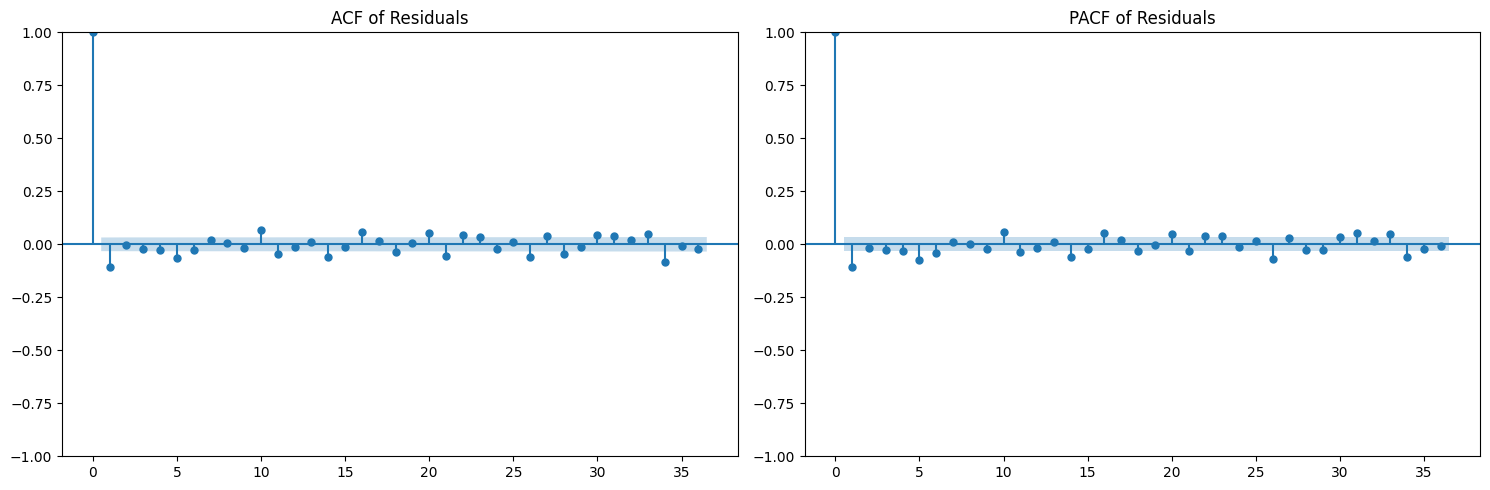

In [17]:
#Observe ACF and PACF
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
sm.graphics.tsa.plot_acf(y_train, ax=axs[0])
axs[0].set_title('ACF of Residuals')

sm.graphics.tsa.plot_pacf(y_train, ax=axs[1])
axs[1].set_title('PACF of Residuals') 

plt.tight_layout()
plt.show()

First, we test a pure GARCH model and upon iteration, a ARX-GJR-GARCH Model obtains the lowest AIC value

                              AR-X - GJR-GARCH Model Results                             
Dep. Variable:                              None   R-squared:                       0.020
Mean Model:                                 AR-X   Adj. R-squared:                  0.019
Vol Model:                             GJR-GARCH   Log-Likelihood:               -3628.63
Distribution:      Standardized Skew Student's t   AIC:                           7279.25
Method:                       Maximum Likelihood   BIC:                           7347.62
                                                   No. Observations:                 3697
Date:                           Thu, Oct 31 2024   Df Residuals:                     3692
Time:                                   10:02:11   Df Model:                            5
                                      Mean Model                                      
                         coef    std err          t      P>|t|        95.0% Conf. Int.
----------------

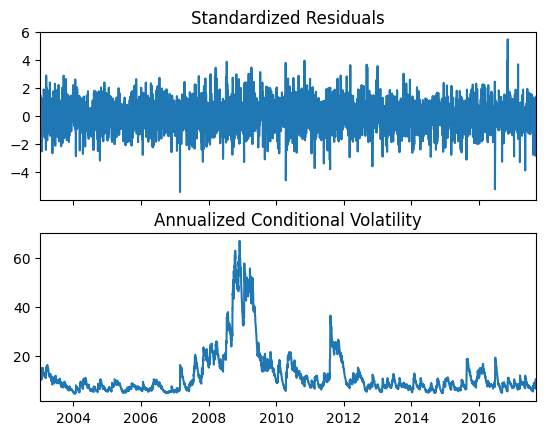

In [21]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson
GM_model = arch_model(y_train, x=X_train, mean="ARX", lags=1, vol="GARCH", p=1, q=1, o=1, dist="skewt")
GM_result = GM_model.fit(disp="off")
print(GM_result.summary())
'---------------------'
fig = GM_result.plot(annualize="D")
'---------------------'
GM_aic = GM_result.aic
print(f"GARCH-M AIC: {GM_aic}")

In [33]:
Gresid = GM_result.resid
acorr_ljungbox(GM_result.resid.dropna(), lags = 10)

,lb_stat,lb_pvalue
1,0.526923,0.467903
2,0.863409,0.649401
3,2.104088,0.551086
4,4.834500,0.304704
5,18.618675,0.002263
6,20.269514,0.002479
7,22.929508,0.001753
8,23.728408,0.002545
9,23.729420,0.004750
10,42.127194,0.000007


In [34]:
durbin_watson(GM_result.resid.dropna())

2.0173170272467353

Therefore, there autocorrelation still present in the residuals of ARX-GJR-GARCH Model after the 4th lag. We attempt to improve the autocorrelation by fitting it first through a ARIMA model then run the residuals of the ARIMA model to GARCH

### ARIMA-GARCH Model

In [41]:
import pmdarima as pm

arima = pm.auto_arima(y=y_train, X=X_train, start_P=1, start_Q=1, seasonal=False)
print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  resid   No. Observations:                 3698
Model:               SARIMAX(2, 0, 2)   Log Likelihood               -5404.838
Date:                Thu, 31 Oct 2024   AIC                          10819.677
Time:                        10:19:48   BIC                          10850.755
Sample:                             0   HQIC                         10830.737
                               - 3698                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0910      5.923      0.015      0.988     -11.519      11.701
ar.L2          0.4574      4.365      0.105      0.917      -8.098       9.012
ma.L1         -0.1103      5.921     -0.019      0.9

In [44]:
G_model = arch_model(arima.resid(), mean="zero", vol="GARCH", dist="t", p=1, q=1)
G_fit =G_model.fit(disp="off", cov_type="robust")
print(G_fit.summary())

                          Zero Mean - GARCH Model Results                           
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -3698.25
Distribution:      Standardized Student's t   AIC:                           7404.51
Method:                  Maximum Likelihood   BIC:                           7429.37
                                              No. Observations:                 3698
Date:                      Thu, Oct 31 2024   Df Residuals:                     3698
Time:                              10:24:27   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omeg

In [48]:
AG_resid = G_fit.resid
acorr_ljungbox(G_fit.resid.dropna(), lags = 10)

,lb_stat,lb_pvalue
1,0.089540,0.764763
2,1.326056,0.515289
3,1.370902,0.712369
4,1.372828,0.848904
5,2.591797,0.762611
6,2.715515,0.843611
7,4.086409,0.769773
8,5.134884,0.743067
9,11.010037,0.275022
10,17.624095,0.061646


In [49]:
durbin_watson(G_fit.resid.dropna())

2.0087447044046325

Therefore, we can conclude that a ARIMA-GARCH model is more suitable as it removes all autocorrelation within the residuals and will be using it to forecast the volatility of XLF

### Run Rolling Predictions

In [52]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="statsmodels")
from statsmodels.tsa.arima.model import ARIMA
from arch.__future__ import reindexing

pred = []
for i in range(len(X_test)):
    roll_x_train = X_scaled.iloc[:len(y_train)+i]
    roll_y_train = y_scaled.iloc[:len(y_train)+i]
    arima = ARIMA(roll_y_train, order=(2, 0, 2), exog=roll_x_train)
    arima_result = arima.fit()
    garch_x = arch_model(arima_result.resid, mean="zero", vol="Garch", p=1, q=1)
    garch_x_fit = garch_x.fit(disp="off", cov_type="robust")
    pred.append(np.sqrt(garch_x_fit.forecast(horizon=1).variance.values[-1,:][0]))
    print(f"Pred for {roll_x_train.index[-1]} completed")

Pred for 2017-09-12 00:00:00 completed
Pred for 2017-09-13 00:00:00 completed
Pred for 2017-09-14 00:00:00 completed
Pred for 2017-09-15 00:00:00 completed
Pred for 2017-09-18 00:00:00 completed
Pred for 2017-09-19 00:00:00 completed
Pred for 2017-09-20 00:00:00 completed
Pred for 2017-09-21 00:00:00 completed
Pred for 2017-09-22 00:00:00 completed
Pred for 2017-09-25 00:00:00 completed
Pred for 2017-09-26 00:00:00 completed
Pred for 2017-09-27 00:00:00 completed
Pred for 2017-09-28 00:00:00 completed
Pred for 2017-09-29 00:00:00 completed
Pred for 2017-10-02 00:00:00 completed
Pred for 2017-10-03 00:00:00 completed
Pred for 2017-10-04 00:00:00 completed
Pred for 2017-10-05 00:00:00 completed
Pred for 2017-10-06 00:00:00 completed
Pred for 2017-10-09 00:00:00 completed
Pred for 2017-10-10 00:00:00 completed
Pred for 2017-10-11 00:00:00 completed
Pred for 2017-10-12 00:00:00 completed
Pred for 2017-10-13 00:00:00 completed
Pred for 2017-10-16 00:00:00 completed
Pred for 2017-10-17 00:00

In [53]:
def evaluate_smape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    numerator = np.abs(y_pred - y_true)
    denominator = (np.abs(y_true) + np.abs(y_pred))/2
    return "sMAPE :", np.mean(numerator/denominator) * 100

def evaluate_rmse(y_true, y_pred):
    squared_errors = (y_true - y_pred)**2
    rmse = np.sqrt(np.mean(squared_errors))
    return "RMSE (squared residuals vs predicted variance):", rmse

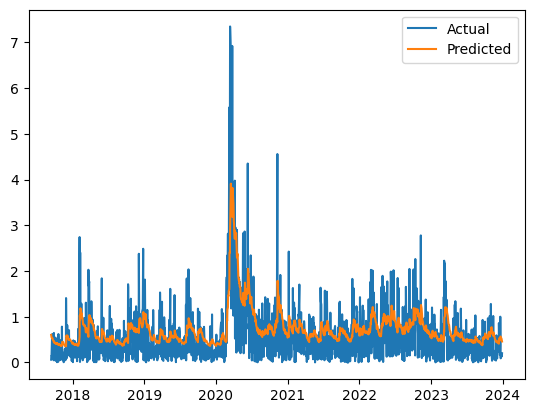

In [61]:
pred_df = pd.Series(pred, index=X_test.index)
plt.plot(y_test.abs(), label="Actual")
plt.plot(pred_df, label="Predicted")
plt.legend()


In [56]:
print(evaluate_rmse(y_test, pred_df))
print(evaluate_smape(y_test, pred_df))

('RMSE (squared residuals vs predicted variance):', 1.1958784024682736)
('sMAPE :', 135.07834512258296)


In [63]:
pred_df.to_csv("/Users/joshuawong/Desktop/XLF_pred.csv")